# LLM usage Analysis

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
%matplotlib inline
import matplotlib.pyplot as plt

In [26]:
df = pd.read_csv('../datasets/projects_parameter_assignments.csv')
df = df.loc[df['parameter'] != 'model']
print("Total number of parameter configurations: ", df.shape[0])
number_of_projects = df['project_name'].nunique()
print("Number of projects:", number_of_projects)

Total number of parameter configurations:  7892
Number of projects: 363


## How many projects define each parameter?

In [15]:
df_unique = df.drop_duplicates(subset=['project_name', 'parameter'], keep='first')
df_2 = df_unique.drop(columns=['path', 'lineno', 'value'])
df_2.value_counts().groupby(['parameter']).count().apply(lambda x: f'{x} ({(x / number_of_projects)*100})')

parameter
frequency_penalty      67 (18.457300275482094)
max_tokens             206 (56.74931129476584)
min_p                    16 (4.40771349862259)
presence_penalty        70 (19.28374655647383)
repetition_penalty     73 (20.110192837465565)
temperature            328 (90.35812672176309)
top_k                  155 (42.69972451790633)
top_p                 181 (49.862258953168045)
Name: count, dtype: str

## How many parameters does each project define?

count
2    92
1    84
3    66
4    49
5    30
6    18
7    16
8     8
Name: count, dtype: int64

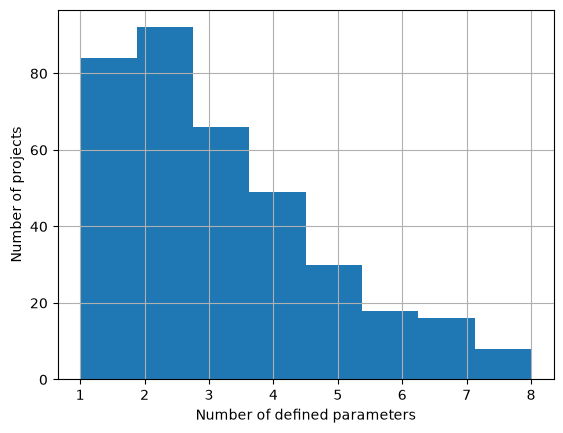

In [29]:
df_unique = df.drop_duplicates(subset=['project_name', 'parameter', 'value'], keep='first')
df_2 = df_unique.drop(columns=['path', 'lineno', 'value'])
t = df_2.value_counts().groupby(['project_name']).count()
t.hist(bins=8)
plt.xlabel('Number of defined parameters')
plt.ylabel('Number of projects')
plt.savefig('hist.png')
t.value_counts()

## How many parameters are defined in a project on average?

In [17]:
df_2 = df.drop(columns=['path', 'lineno', 'value'])
df_2.value_counts().groupby(['project_name']).count().mean()
sorted(list(df_2.value_counts().groupby(['project_name']).count()))[number_of_projects//2]

3

In [18]:
def count_ocurrences(elem, a_list):
    count = 0
    for x in a_list:
        if x == elem:
            count += 1
    return count

In [20]:
total_parameter = 8
df_4 = df.drop(columns=['path', 'lineno', 'value'])


d = df_4.value_counts().to_dict()
t = df_4.value_counts().groupby(['project_name']).count()

new_d = {}
for k1, k2 in sorted(d.keys()):
    if not k1 in new_d.keys():
        new_d[k1] = [k2]
    else:
        new_d[k1].append(k2)

a_dict = {}
for a_list in new_d.values():
    l = "d" + str(len(a_list))
    if l in a_dict.keys():
        a_dict[l].append(tuple(a_list))
    else:
        a_dict[l] = [tuple(a_list)]

for k, v in a_dict.items():
    print(k)
    for x in set(v):
        t = count_ocurrences(x, v)
        print(x, t, (t/len(v)*100))

d7
('frequency_penalty', 'min_p', 'presence_penalty', 'repetition_penalty', 'temperature', 'top_k', 'top_p') 2 12.5
('max_tokens', 'min_p', 'presence_penalty', 'repetition_penalty', 'temperature', 'top_k', 'top_p') 1 6.25
('frequency_penalty', 'max_tokens', 'min_p', 'presence_penalty', 'temperature', 'top_k', 'top_p') 1 6.25
('frequency_penalty', 'max_tokens', 'presence_penalty', 'repetition_penalty', 'temperature', 'top_k', 'top_p') 11 68.75
('frequency_penalty', 'max_tokens', 'min_p', 'presence_penalty', 'repetition_penalty', 'temperature', 'top_p') 1 6.25
d5
('max_tokens', 'presence_penalty', 'temperature', 'top_k', 'top_p') 1 3.3333333333333335
('frequency_penalty', 'max_tokens', 'presence_penalty', 'temperature', 'top_k') 1 3.3333333333333335
('max_tokens', 'min_p', 'temperature', 'top_k', 'top_p') 1 3.3333333333333335
('max_tokens', 'presence_penalty', 'repetition_penalty', 'temperature', 'top_p') 1 3.3333333333333335
('max_tokens', 'repetition_penalty', 'temperature', 'top_k', '

## What values do the parameters take? What is the most common value? Does it match the default values?

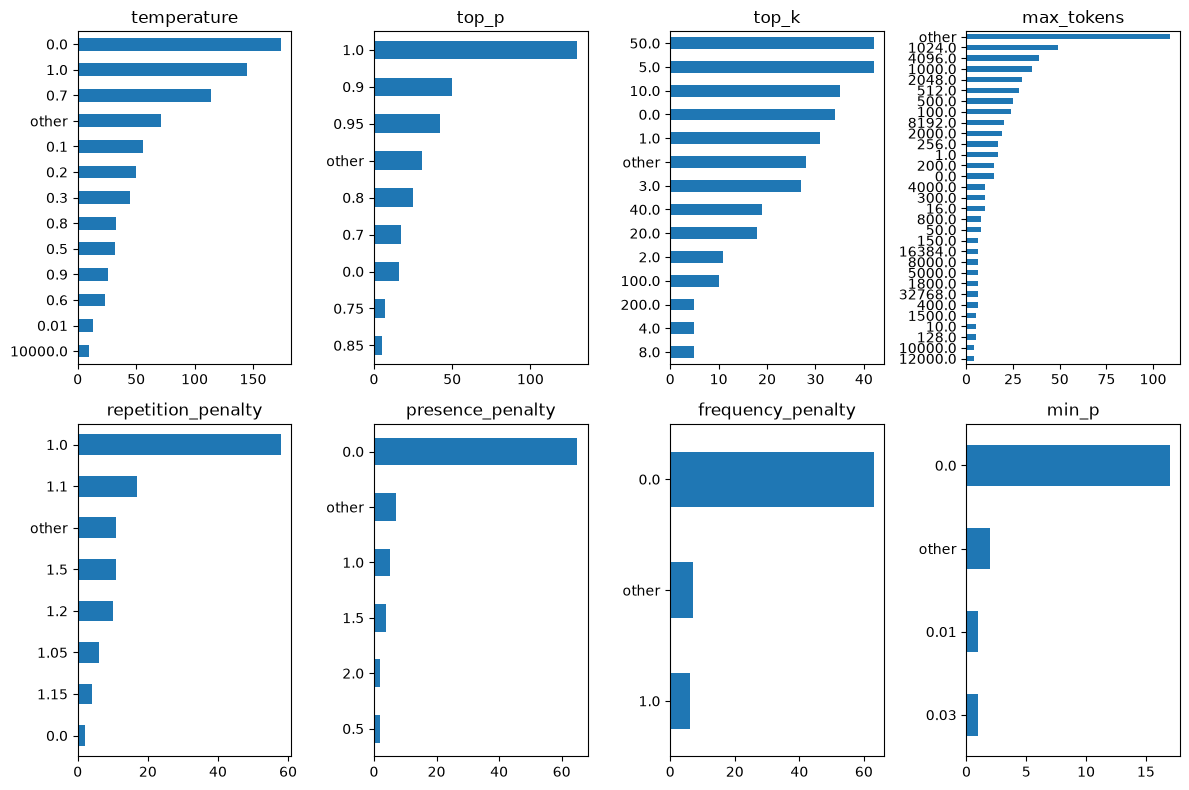

In [27]:
parameters = ['temperature', 'top_p', 'top_k', 'max_tokens', 'repetition_penalty', 'presence_penalty', 'frequency_penalty', 'min_p']

df_unique = df.drop_duplicates(subset=['project_name', 'parameter', 'value'], keep='first')
df_5 = df_unique.drop(columns=['project_name', 'path', 'lineno'])
df_5['value'] = df_5['value'].dropna()
df_5['value'] = pd.to_numeric(df_5['value'], errors='coerce')

fig, axes = plt.subplots(2, 4, figsize=(12, 8))
row = 0
column = 0

for parameter in parameters:
    param_df = df_5.loc[df_5['parameter'] == parameter]
    param_df = param_df['value']

    total_values = param_df.size
    values_count = param_df.value_counts()
    values_count = pd.to_numeric(values_count, errors='coerce')
    values_count = values_count.sort_values(ascending=False)
    values_count = values_count.to_dict()
    current_percentage = 0
    current_values = 0
    limit_percentage=0.90 if parameter != 'max_tokens' else 0.80
    new_value_count = {}
    other_count = 0
    for n, (idx, count) in enumerate(values_count.items()):
        if current_percentage < limit_percentage:
            new_value_count[idx] = count
            current_values += count
            current_percentage = current_values / total_values
        else:
            other_count += count
    if other_count > 0:
        new_value_count['other'] = other_count
    new_value_count = pd.Series(data=new_value_count, index=new_value_count.keys())
    new_value_count = new_value_count.sort_values()
    new_value_count.plot.barh(ax=axes[row, column], title=parameter)
    column += 1
    if column > 3:
        row = 1
        column = 0

plt.tight_layout();
plt.show()
new_value_count
fig.savefig('parameters_values.png')